In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import tensorflow as tf
from tensorflow import keras

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

<ipython-input-3-04f4dd9291cd>:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(train_labels[i])])


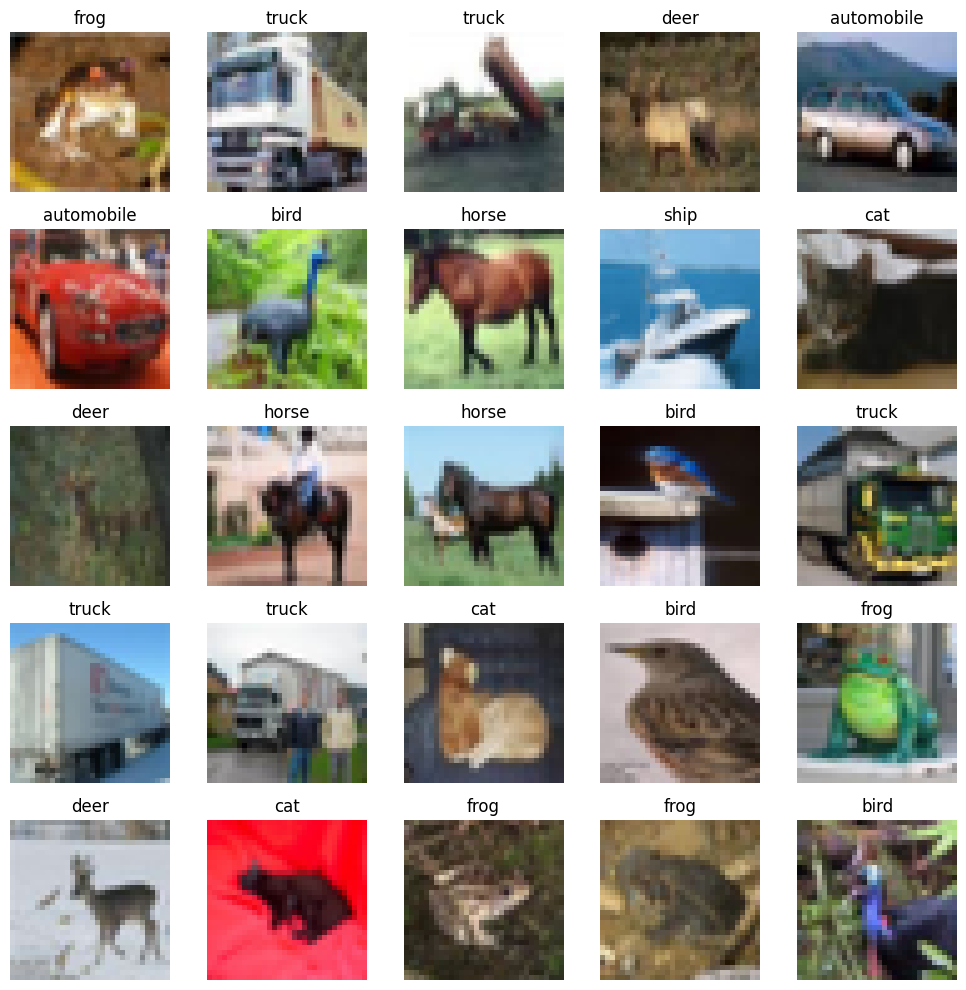

In [3]:
# --- [CELL 2]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# === BEFORE (original) ===
# import matplotlib.pyplot as plt
# 
# class_names = "airplane automobile bird cat deer dog frog horse ship truck".split()
# 
# plt.figure(figsize=(10, 10))
# for i in range(25):
#     plt.subplot(5, 5, i+1)
#     plt.imshow(train_images[i].astype("uint8"))
#     plt.title(class_names[train_labels[i]])
#     plt.axis("off")

# === AFTER (edited) ===
import matplotlib.pyplot as plt

class_names = "airplane automobile bird cat deer dog frog horse ship truck".split()

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(train_images[i].astype("uint8"))
    plt.title(class_names[int(train_labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Verify fixed behavior: scalar indexing into class_names works with CIFAR-10 labels.
assert hasattr(train_labels, "shape"), "train_labels must exist from previous cell"
assert len(class_names) == 10, "Expected CIFAR-10 class_names list"

scalar_idx = int(train_labels[0, 0]) if getattr(train_labels, "ndim", 1) > 1 else int(train_labels[0])
label_name = class_names[scalar_idx]
assert isinstance(label_name, str) and label_name in class_names, "Scalar label index should map to a valid class name"

# Regression guard: buggy path uses a (1,) array as list index and must raise TypeError.
array_idx = train_labels[0]
raised_type_error = False
try:
    _ = class_names[array_idx]
except TypeError:
    raised_type_error = True
assert raised_type_error, "Expected TypeError when indexing class_names with a (1,) array label"

# Optional/tolerant plotting check: only validate titles if a figure/axes exists.
if plt.get_fignums():
    fig = plt.figure(plt.get_fignums()[-1])
    axes = fig.get_axes()
    if axes:
        title0 = axes[0].get_title()
        if title0:
            assert title0 in class_names, "Rendered subplot title should be a known class name"